In [253]:
import numpy as np  #Importing librarys
import matplotlib.pyplot as plt

In [254]:
x = np.arange(1, 21) #outlining data sets for furture use
x_covid = np.arange(1, 17)
y_covid = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -1.6, 2.4, 3.3])
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

In [255]:
def cubic_spline(x, y): #creating the spline data up through thomas method
  n = len(x)
  h = np.diff(x)

  A = np.zeros(n - 2)
  B = np.zeros(n - 2)
  C = np.zeros(n - 2)
  D = np.zeros(n - 2)

  for i in range(0, n - 2):
    A[i] = h[i]
    B[i] = 2 * (h[i] + h[i+1])
    C[i] = h[i+1]
    D[i] = 6 * ((y[i+2] - y[i+1]) / h[i+1] - (y[i+1] - y[i]) / h[i])

  for i in range(1, n-2):
    w = A[i] / B[i-1]
    B[i] = B[i] - w * C[i-1]
    D[i] = D[i] - w * D[i-1]

  z_in = np.zeros(n-2)
  z_in[-1] = D[-1] / B[-1]
  for i in range(n-4, -1, -1):
    z_in[i] = (D[i] - C[i] * z_in[i+1]) / B[i]

  z = np.zeros(n)
  z[1:-1] = z_in
  return z

In [256]:
def eval_spline(x_data, y_data, M, x_query):   #putting spline model into actual points for plotting
  n = len(x_data)
  h = np.diff(x_data)
  i = np.searchsorted(x_data, x_query, side='right') - 1
  i = np.clip(i, 0, n - 2)
  hi = h[i]
  dx_left = x_query - x_data[i]
  dx_right = x_data[i+1] - x_query
  S = (
    (M[i] / (6*hi)) * dx_right**3 +
    (M[i+1] / (6*hi)) * dx_left**3 +
    (y_data[i] /hi - M[i] *hi/6) * dx_right +
    (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left
  )
  return S

In [257]:
def least_squares(X, Y):  #creating slope and intercept of least squares model
  x_sum = np.sum(X)
  y_sum = np.sum(Y)
  x_sqr = np.sum(X * X)
  xy = np.sum(X * Y)
  n = len(X)
  m = (n * xy - x_sum * y_sum) / (n * x_sqr - x_sum * x_sum)
  c = (y_sum - m * x_sum) / n
  return m, c

In [258]:
def eval_square(m, c, x): #turning least squares into actual points
    y_val = m*x + c
    return y_val

In [259]:
def polyfit(x, y, d): #creating coefficents for polynomial model
  n = len(x)
  V = np.zeros((n, d+1))
  for i in range(n):
    for j in range(d+1):
          V[i, j] = x[i]**j
  VT_V = V.T @ V
  VT_y = V.T @ y
  a = np.linalg.solve(VT_V, VT_y)
  return a

In [260]:
def eval_poly(a, b): # creating actual points from polynomial
    y_val = np.zeros_like(b, dtype=float)
    degree = len(a) - 1
    for j in range(degree + 1):
        y_val += a[j] * b**j
    return y_val

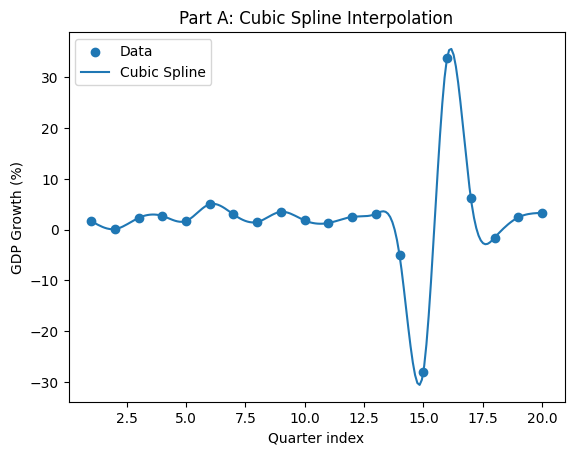

In [261]:
#part A
# Compute spline
M = cubic_spline(x, y)

# Evaluate spline for plotting
x_vals = np.linspace(1, 20, 200)
y_spline = [eval_spline(x, y, M, xv) for xv in x_vals]

# Plot
plt.scatter(x, y, label='Data')
plt.plot(x_vals, y_spline, label='Cubic Spline')
plt.xlabel("Quarter index")
plt.ylabel("GDP Growth (%)")
plt.title("Part A: Cubic Spline Interpolation")
plt.legend()
plt.show()

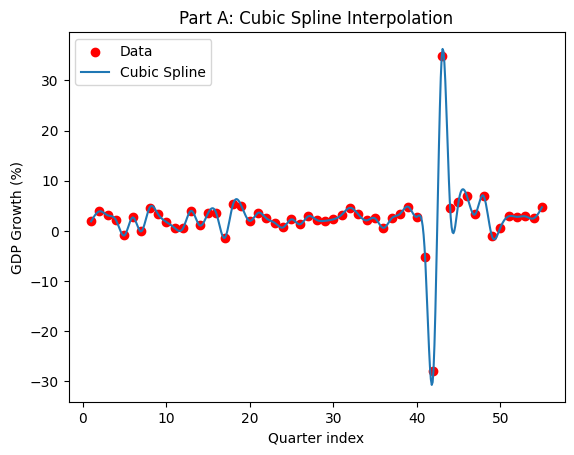

In [262]:
#for full data set(number from FRED database)
x_2= np.arange(1, 56)
y_2= ([1.9,3.9,3.1,2.1,-0.9,2.7,-0.1,4.6,3.4,1.8,0.6,0.5,4,1.1,3.5,3.5,-1.4,5.3,5,2,3.6,2.5,1.6,0.7,2.3,1.3,2.9,2.2,2,2.3,3.2,4.6,3.3,2.1,2.5,0.6,2.5,3.4,4.8,2.8,-5.2,-28,34.9,4.6,5.7,7,3.3,7,-1,0.6,2.9,2.8,2.9,2.5,4.7,])
# Compute spline
M = cubic_spline(x_2, y_2)
#turning to real values
x_vals = np.linspace(1, 55, 500)
y_spline = [eval_spline(x_2, y_2, M, xv) for xv in x_vals]

# Plotting
plt.scatter(x_2, y_2, color='red', label='Data')
plt.plot(x_vals, y_spline, label='Cubic Spline')
plt.xlabel("Quarter index")
plt.ylabel("GDP Growth (%)")
plt.title("Part A: Cubic Spline Interpolation")
plt.legend()
plt.show()

Part a discussion:
1. The cubic spline comes from solving the equation y = a + b(x-xi)+c(x-xi)^2+d(x-xi)^3
giving four unknown per point.
The spline must also meet the requirement of its value, first direivative, and second dirivative being continous and exact to the data as it moves through. A nateral spline is a spline with a second dirivative of zero at the endpoints
2. The spline remains smooth and resonable as it moves through all points present
3. Because a spline must pass through every point exactly, the runge error occurs. This means that large outliers such as the covid data here cause a major occilation and discrepency in the model, comprimising stability for exactness. This means least squares is a more preferable model here as it will not be compromised by trying to reach the outlier and instead represent the overall trend.

RMSE (Cubic Spline): 
1.589609576479376e-15
RMSE (4th-degree Polynomial): 
9.96532678651953


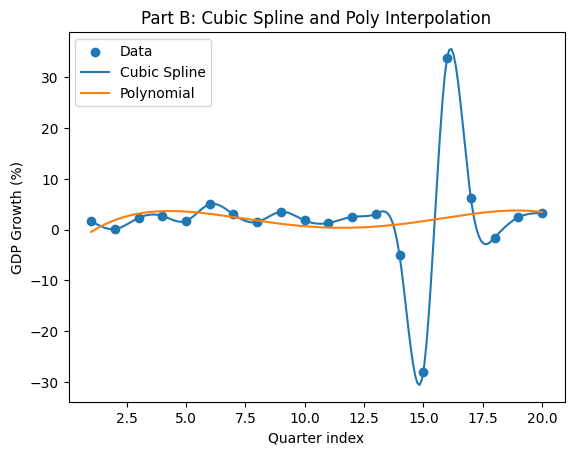

In [263]:
#Part B
# Compute spline
M = cubic_spline(x, y)

# Evaluate spline for plotting
x_vals = np.linspace(1, 20, 200)
y_spline = [eval_spline(x, y, M, xv) for xv in x_vals]
y_spline_data = [eval_spline(x, y, M, xv) for xv in x] #these sets needed so that calculated values only compared to given values
rmse_spline = np.sqrt(np.mean((y - y_spline_data)**2))

#creating and evaluating polynomial fit
coe = polyfit(x, y, 4)
y_poly = eval_poly(coe, x_vals)
y_poly_data = eval_poly(coe, x)
rmse_poly = np.sqrt(np.mean((y - y_poly_data)**2))
print(f"RMSE (Cubic Spline): ")
print( rmse_spline)
print("RMSE (4th-degree Polynomial): ")
print(rmse_poly)

# Plot
plt.scatter(x, y, label='Data')
plt.plot(x_vals, y_spline, label='Cubic Spline')
plt.plot(x_vals, y_poly, label='Polynomial')
plt.xlabel("Quarter index")
plt.ylabel("GDP Growth (%)")
plt.title("Part B: Cubic Spline and Poly Interpolation")
plt.legend()
plt.show()

0.00014705882352961238


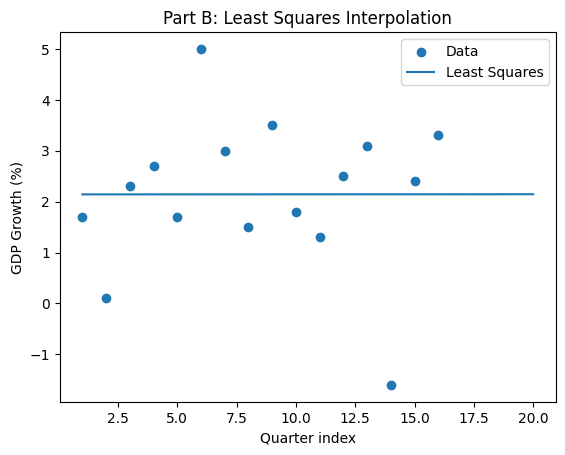

In [264]:
#least squares linear repersentation
m, c = least_squares(x_covid, y_covid)
y_ls = eval_square(m, c, x_vals)
print(m)

# Plot
plt.scatter(x_covid, y_covid, label='Data')
plt.plot(x_vals, y_ls, label='Least Squares')
plt.xlabel("Quarter index")
plt.ylabel("GDP Growth (%)")
plt.title("Part B: Least Squares Interpolation")
plt.legend()
plt.show()

Part B Discussion
1. While the spline better matches exact points, the poly repersentation did a better job of identifing the trend, as it did not jump at the outliers. This means that while the spline is a good fit for interpolation of the data, in the case the poly was better for approximation as it more accuratly found the trend present.
2. The near zero slope shows how economic policy tries to get GDP growth steady, between 2 and 3 percent as the goldilocks zone. The zero slope and the line being in this zone asserts that, without outliers, US policy is achiving this trend well on average.

Part C
I would use the poly fit model for policy creation as it shows a better overall picture with less isolation, and you cana ctually see the slight growth and decay cycle that economic policy aims to maintain for stability. While the spline modle does better map the data(having an RMSE score of 0), it jumps and occilates the meet outliers, not showing any actual trend that can be actionable. In contrast the poly model still has a decently low RMSE score of around 9, but it does not randomly jump, and thus can better be used to predict future outcomes if conditions remain stable.